<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Image Enhancement</b>
</h1>
<div style="font-family:'Times New Roman';">
Enhancement means making an image easier to see or work with. Three things here: fixing contrast with histogram methods, removing noise with a few diffrent filters, and filtering in the frequency domain with low pass and high pass masks.
</div>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

gray = cv2.cvtColor(cv2.imread('image.jpeg'), cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, (480, 360))
print('gray', gray.shape)

gray (360, 480)


# Part A: Histogram processing

first lets make a **low contrast** version on purpose by squashing the intensity range, so the enhancement actualy has something to fix.

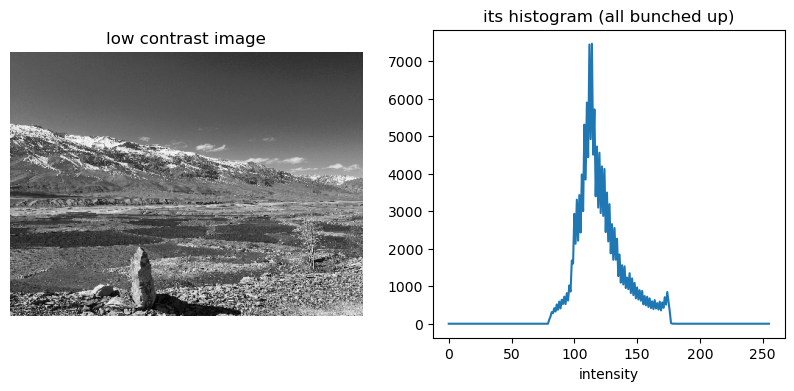

In [2]:
low = (gray * 0.4 + 80).astype(np.uint8)   # squashed into a narrow bright band

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(low, cmap='gray'); ax[0].set_title('low contrast image'); ax[0].axis('off')
ax[1].plot(cv2.calcHist([low], [0], None, [256], [0, 256]))
ax[1].set_title('its histogram (all bunched up)'); ax[1].set_xlabel('intensity')
plt.show()

**Histogram Equalization:** spreads the bunched up intensities back across the full 0 to 255 range, which boosts contrast.

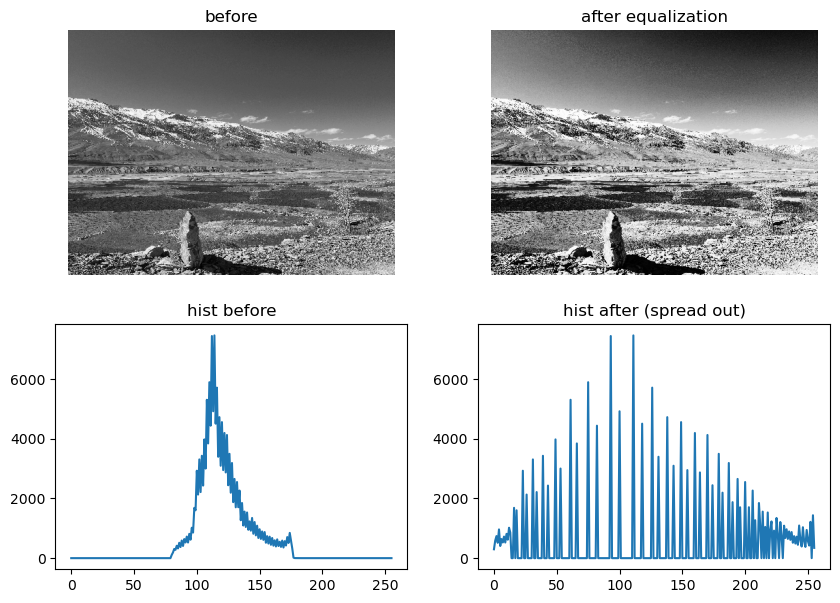

In [3]:
eq = cv2.equalizeHist(low)

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0,0].imshow(low, cmap='gray'); ax[0,0].set_title('before'); ax[0,0].axis('off')
ax[0,1].imshow(eq, cmap='gray');  ax[0,1].set_title('after equalization'); ax[0,1].axis('off')
ax[1,0].plot(cv2.calcHist([low], [0], None, [256], [0, 256])); ax[1,0].set_title('hist before')
ax[1,1].plot(cv2.calcHist([eq],  [0], None, [256], [0, 256])); ax[1,1].set_title('hist after (spread out)')
plt.show()

**CLAHE (Adaptive Equalization):** does the same thing but tile by tile, so one bright region doesnt wash out the rest. the clip limit stops it from over boosting noise.

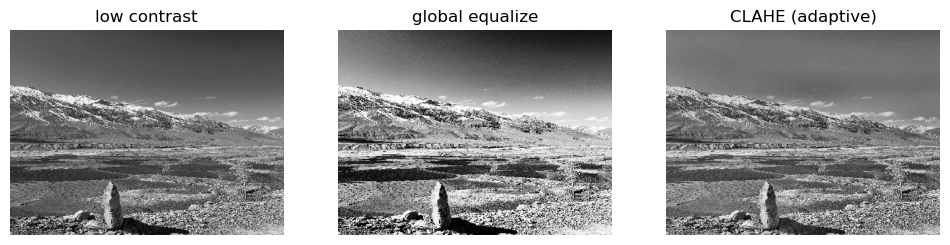

In [7]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(low)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(low, cmap='gray'); plt.title('low contrast'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(eq, cmap='gray');  plt.title('global equalize'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cl, cmap='gray');  plt.title('CLAHE (adaptive)'); plt.axis('off')
plt.show()

# Part B: Removing noise

real images pick up noise from the sensor. lets add some on purpose (gaussian + a bit of salt and pepper) and then try diffrent ways to clean it.

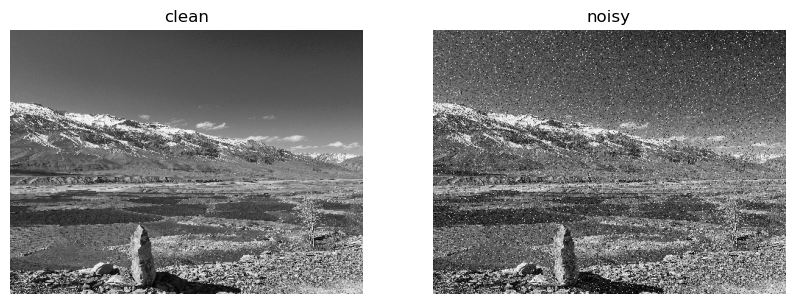

In [14]:
noisy = gray.astype(np.float32) + np.random.normal(0, 20, gray.shape)
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# salt and pepper, flip some pixels to pure white / pure black
num = int(0.02 * gray.size)
ys = np.random.randint(0, gray.shape[0], num); xs = np.random.randint(0, gray.shape[1], num)
noisy[ys, xs] = 255
ys = np.random.randint(0, gray.shape[0], num); xs = np.random.randint(0, gray.shape[1], num)
noisy[ys, xs] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(gray, cmap='gray');  ax[0].set_title('clean'); ax[0].axis('off')
ax[1].imshow(noisy, cmap='gray'); ax[1].set_title('noisy'); ax[1].axis('off')
plt.show()

now four diffrent denoising filters:

- **Gaussian blur** : averages with a weighted window, smooths everything (also the edges)
- **Median blur** : takes the median of the window, kills salt and pepper really well
- **Bilateral** : smooths but keeps edges sharp
- **Non local means** : looks for similiar patches across the image, the strongest one

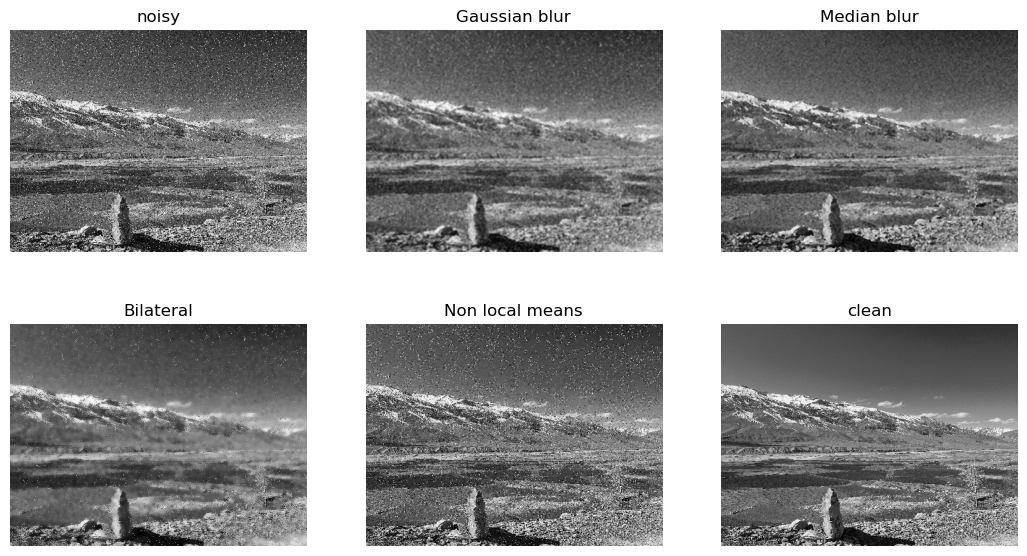

In [9]:
gauss  = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 3)
bilat  = cv2.bilateralFilter(noisy, 9, 75, 75)
nlm    = cv2.fastNlMeansDenoising(noisy, None, 15, 7, 21)

titles = ['noisy', 'Gaussian blur', 'Median blur', 'Bilateral', 'Non local means', 'clean']
imgs   = [noisy, gauss, median, bilat, nlm, gray]

plt.figure(figsize=(13, 7))
for k in range(6):
    plt.subplot(2, 3, k + 1); plt.imshow(imgs[k], cmap='gray')
    plt.title(titles[k]); plt.axis('off')
plt.show()

median blur cleans the salt and pepper the best, bilateral keeps the edges sharpest, gaussian smudges everything. so the right filter depends on the noise.

# Part C: Frequency domain (Fourier)

any image can be moved into the **frequency domain** with the Fourier transform. low frequencies are the smooth areas, high frequencies are the edges, fine detail and noise. once there we can keep or drop frequencies with a mask.

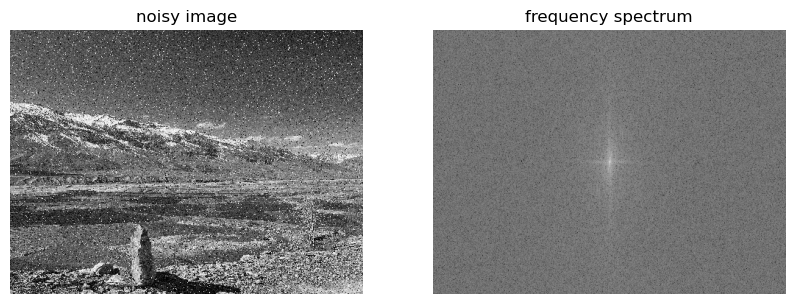

In [10]:
f = np.fft.fft2(noisy)
fshift = np.fft.fftshift(f)             # move the 0 frequency to the centre
spectrum = np.log(1 + np.abs(fshift))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(noisy, cmap='gray'); plt.title('noisy image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(spectrum, cmap='gray'); plt.title('frequency spectrum'); plt.axis('off')
plt.show()

**Low pass filter:** keep only the centre (low frequencies), drop the outside. that removes fine noise and smooths the image. the mask is a white circle in the middle.

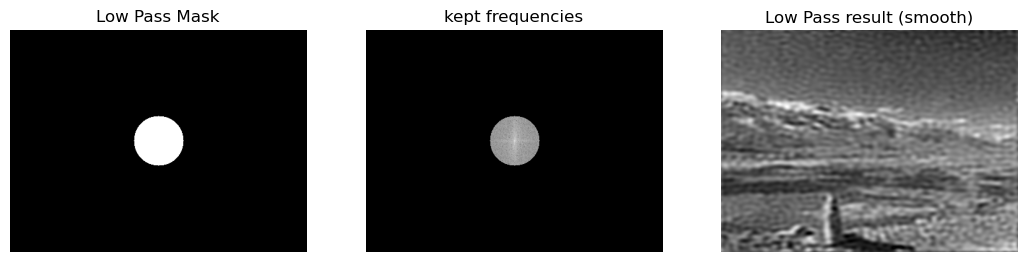

In [11]:
rows, cols = noisy.shape
crow, ccol = rows // 2, cols // 2

lp_mask = np.zeros((rows, cols), np.uint8)
cv2.circle(lp_mask, (ccol, crow), 40, 1, -1)   # 1 inside the circle, 0 outside

lp_applied = fshift * lp_mask
lp_img = np.abs(np.fft.ifft2(np.fft.ifftshift(lp_applied)))

plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1); plt.imshow(lp_mask, cmap='gray'); plt.title('Low Pass Mask'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(np.log(1 + np.abs(lp_applied)), cmap='gray'); plt.title('kept frequencies'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(lp_img, cmap='gray'); plt.title('Low Pass result (smooth)'); plt.axis('off')
plt.show()

**High pass filter:** the opposite, drop the centre and keep the outside, so only the edges and detail survive. the mask is a black circle in the middle.

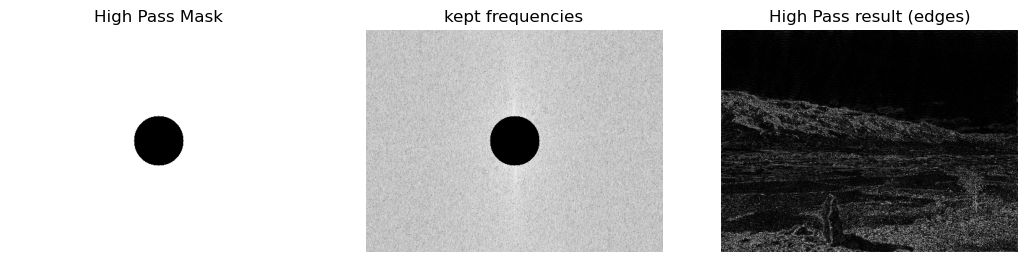

In [12]:
hp_mask = np.ones((rows, cols), np.uint8)
cv2.circle(hp_mask, (ccol, crow), 40, 0, -1)   # 0 inside the circle, 1 outside

f2 = np.fft.fftshift(np.fft.fft2(gray))
hp_applied = f2 * hp_mask
hp_img = np.abs(np.fft.ifft2(np.fft.ifftshift(hp_applied)))

plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1); plt.imshow(hp_mask, cmap='gray'); plt.title('High Pass Mask'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(np.log(1 + np.abs(hp_applied)), cmap='gray'); plt.title('kept frequencies'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(hp_img, cmap='gray'); plt.title('High Pass result (edges)'); plt.axis('off')
plt.show()

### what i learned

histogram equalization and CLAHE fix contrast, the blur filters remove noise (median for salt and pepper, bilateral to keep edges), and in the frequency domain a low pass mask smooths while a high pass mask pulls out edges. low pass keeps the centre, high pass keeps the outside.